### Step 1: Load and Explore Dataset

In [11]:
#Name_Abdul_Rehman______Roll No:24F-AI-005

In [12]:
import os
import pandas as pd

# Get path from kagglehub download
data_dir = path
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV files found in the dataset path.")

file_path = os.path.join(data_dir, csv_files[0])
df = pd.read_csv(file_path)
print(f"Loaded dataset: {csv_files[0]}")
print(f"Dataset dimensions: {df.shape}")
display(df.head())

Loaded dataset: WA_Fn-UseC_-HR-Employee-Attrition.csv
Dataset dimensions: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Step 2: Data Preprocessing and Feature Engineering

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop redundant or non-informative columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_cleaned = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Map target variable (Attrition) to numeric binary classes
if 'Attrition' in df_cleaned.columns:
    df_cleaned['Attrition'] = df_cleaned['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Split features and label
X = df_cleaned.drop(columns=['Attrition'])
y = df_cleaned['Attrition']

# Detect categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Encode categorical values dynamically
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Split dataset into Train and Test splits (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale continuous numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing completed successfully!")

Preprocessing completed successfully!


### Step 3: Model Training, Evaluation, and Comparison


=== Logistic Regression Performance Summary ===
F1-Score: 0.5000
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.72      0.38      0.50        47

    accuracy                           0.88       294
   macro avg       0.81      0.68      0.72       294
weighted avg       0.86      0.88      0.86       294


=== Decision Tree Performance Summary ===
F1-Score: 0.3191
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       247
           1       0.32      0.32      0.32        47

    accuracy                           0.78       294
   macro avg       0.59      0.59      0.59       294
weighted avg       0.78      0.78      0.78       294


=== Random Forest Performance Summary ===
F1-Score: 0.2034
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.13      0.20        

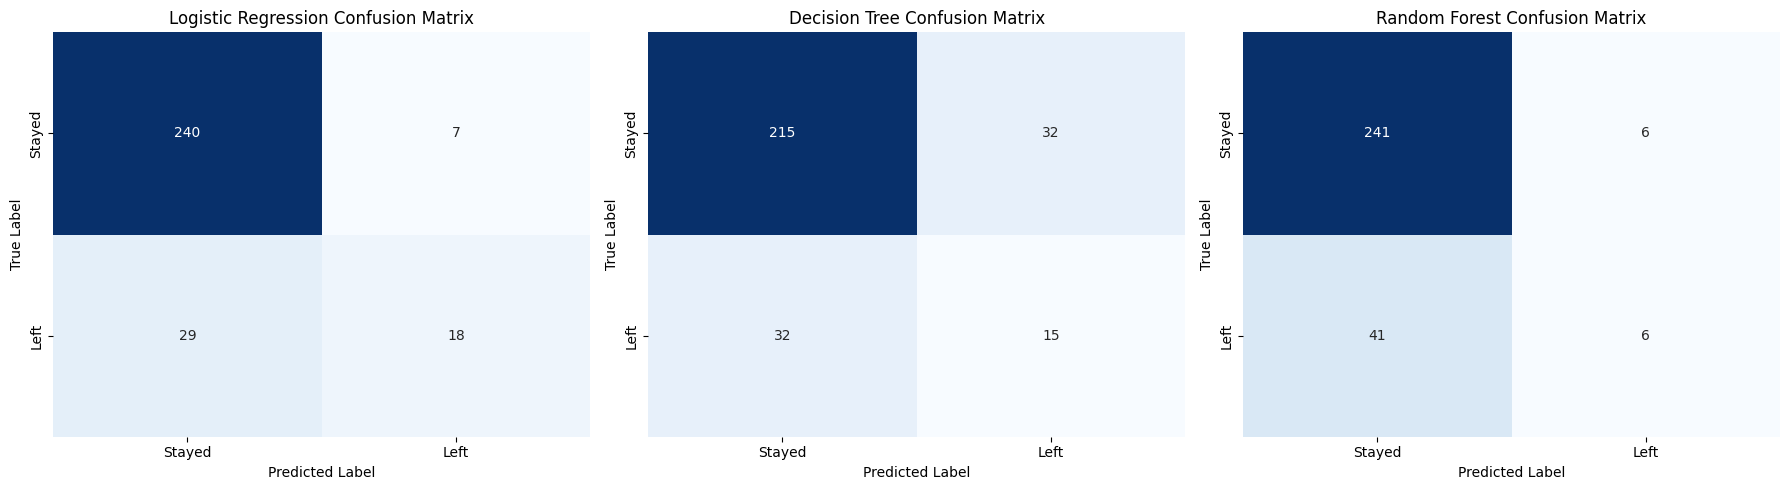

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
plt.figure(figsize=(18, 5))

# Iterative evaluation loop
for idx, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    f1 = f1_score(y_test, y_pred)
    results[name] = {
        "model": model,
        "f1_score": f1,
        "predictions": y_pred
    }

    print(f"\n=== {name} Performance Summary ===")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

    # Display confusion matrices
    plt.subplot(1, 3, idx)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Step 4: Extract and Visualize Feature Importances

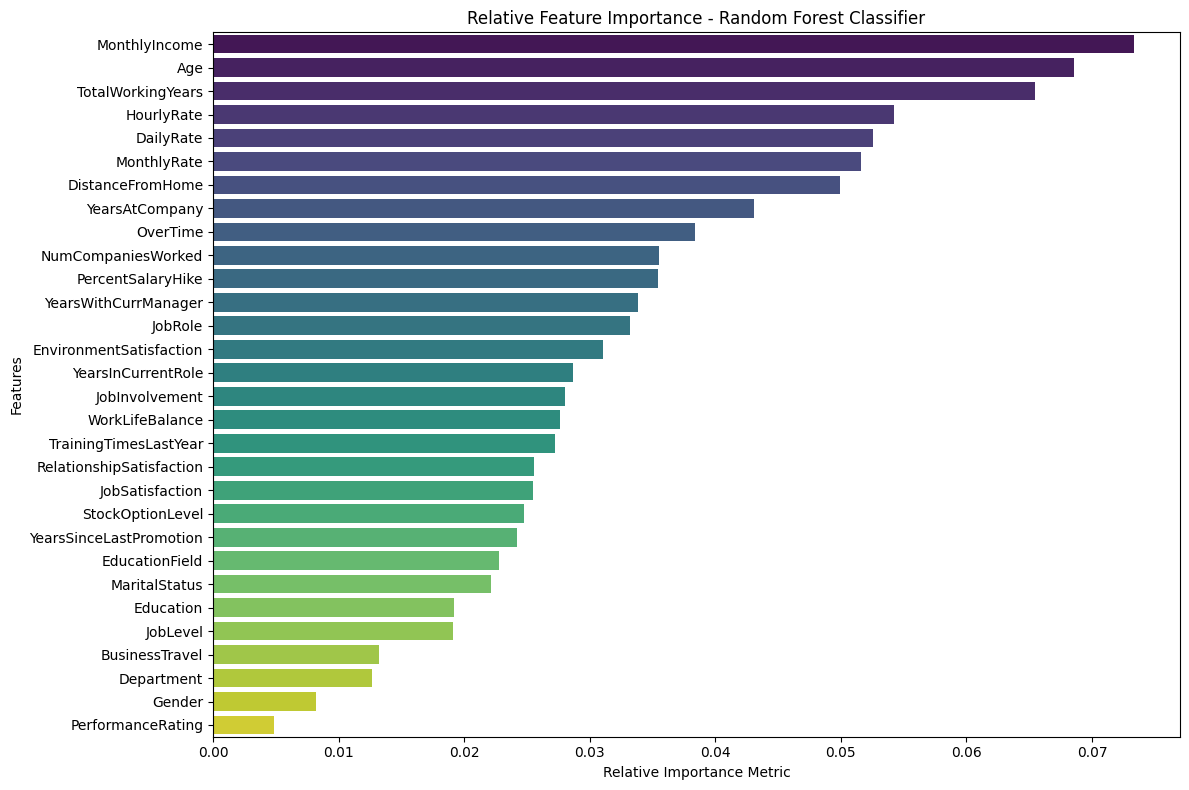

In [15]:
# Visualize feature importances using Random Forest weights
rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Relative Feature Importance - Random Forest Classifier")
sns.barplot(x=importances[indices], y=X.columns[indices], hue=X.columns[indices], palette="viridis", legend=False)
plt.xlabel("Relative Importance Metric")
plt.ylabel("Features")
plt.tight_layout()
plt.show()